# GLM relajado para candidatos de desarrollo y reservas

Este cuaderno estudia si una combinación GLM de métodos de desarrollo mejora al mejor método individual. Reproduce el experimento del cuaderno de referencia usando la misma base y las funciones construidas en este proyecto.

Ruta de lectura: base histórica -> corte a cada fecha de valuación -> candidatos LDF -> pronóstico a dev_60 -> objetivo revelado después -> comparación fuera de muestra.

El GLM combina pronósticos de candidatos; no decide por sí solo que sea el mejor enfoque. Sólo se adopta si mejora WAPE, sesgo y error agregado frente a la base individual en las mismas observaciones.

In [1]:
from pathlib import Path
import importlib.util
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Ajusta únicamente estas rutas si mueves el cuaderno.
RUTA_BASE = Path(r"Data\\generated_monthly_triangles_database.csv")
RUTA_FUNCIONES = Path(r"modulos\Funciones.py")

spec = importlib.util.spec_from_file_location("funciones", RUTA_FUNCIONES)
funciones = importlib.util.module_from_spec(spec)
spec.loader.exec_module(funciones)

base = pd.read_csv(RUTA_BASE)
print(f"Base: {base.shape[0]:,} registros")
print(base['concept'].value_counts().to_string())

Base: 65,340 registros
concept
Exposure           7260
Earned Premium     7260
Loss Incurred      7260
Loss Paid          7260
Claims Reported    7260
Claims Paid        7260
ALAE               7260
Salvages           7260
Subrogation        7260


## Orden recomendado de uso

1. Ejecuta las celdas en orden.
2. Revisa el catálogo para confirmar las variantes.
3. Ejecuta el paso preliminar; es el más lento porque corta la base y recalcula candidatos en cada mes.
4. Revisa seleccion_glm. Si selection_mode es relajado, interpreta el resultado como sensibilidad a colinealidad.
5. Elige el modelo según la tabla final fuera de muestra, no según el tamaño de un coeficiente.

Para una primera corrida rápida, reduce PRELIMINAR_FIN y VALUACION_FIN. Para una corrida final, restaura las fechas completas.

## Paso 1 Parámetros del experimento

Estos parámetros son los principales controles del análisis:

- CONCEPTO: medida de siniestralidad a modelar.
- MADUREZ: desarrollo objetivo. dev_60 es una meta intermedia, no el ultimate final.
- Fechas PRELIMINAR: cortes históricos que generan pronósticos candidatos.
- Fechas VALUACION: fechas cronológicas para entrenar y probar el GLM.
- FECHA_SCORING: hasta cuándo se revelan objetivos para calcular errores.
- MAX_CANDIDATOS_GLM: máximo de pronósticos combinados.
- CORRELACION_MAXIMA: filtro conservador de candidatos parecidos.
- PERMITIR_STACKING_COLINEAL y CORRELACION_RELAJADA: modo laboratorio para explorar candidatos altamente correlacionados.

In [2]:
CONCEPTO = "Loss Incurred"
MADUREZ = 60
PRELIMINAR_INICIO = "2021-01"
PRELIMINAR_FIN = "2024-12"
VALUACION_INICIO = "2022-06"
VALUACION_FIN = "2024-12"
FECHA_SCORING = "2025-12"
# ================================================================
# CONTROLES PRINCIPALES PARA EXPERIMENTAR
# Con PERMITIR_STACKING_COLINEAL=True, 1.0 desactiva el filtro
# relajado. Prueba 0.995 o 0.99 para volverlo más exigente.
# Mantén MAX_CANDIDATOS_GLM bajo para reducir colinealidad.
# ================================================================

MAX_CANDIDATOS_GLM = 3
CORRELACION_MAXIMA = 0.90
PERMITIR_STACKING_COLINEAL = True
CORRELACION_RELAJADA = 0.99
FECHA_GRAFICA = None  # Ejemplo: "2024-12"; None selecciona la fecha con más objetivos revelados.

fechas_preliminares = [
    str(periodo)
    for periodo in pd.period_range(PRELIMINAR_INICIO, PRELIMINAR_FIN, freq="M")
]
fechas_valoracion = [
    str(periodo)
    for periodo in pd.period_range(VALUACION_INICIO, VALUACION_FIN, freq="M")
]

triangulo_completo = funciones.convertir_triangulo(
    base,
    concept=CONCEPTO,
)

if MADUREZ not in triangulo_completo.columns:
    raise ValueError(f"No existe el desarrollo {MADUREZ} en el triángulo.")

objetivo_dev60 = triangulo_completo[MADUREZ].dropna()
print(f"Triángulo: {triangulo_completo.shape}")
print(f"Objetivos observados en dev_{MADUREZ}: {len(objetivo_dev60)}")

Triángulo: (120, 120)
Objetivos observados en dev_60: 60


## Paso 2 Catálogo de candidatos

Se crean 28 alternativas: promedio simple o ponderado, ventanas de 6, 12, 24 y 30 meses, y tratamientos de extremos y atípicos.

Parámetros para experimentar después: ventanas, número de desviaciones estándar, exclusiones específicas o la adición de candidatos Chain Ladder y B-F.

In [3]:
def construir_catalogo_candidatos() -> pd.DataFrame:
    filas = []
    for metodo_base, prefijo in [("simple", "S"), ("ponderado", "VW")]:
        for ventana in [6, 12, 24, 30]:
            exclusiones = ["none", "min_max", "std_same"]
            if ventana in {6, 12}:
                exclusiones.append("std_24p")

            for exclusion in exclusiones:
                metodo = metodo_base
                num_std = None
                periodos_std = None

                if exclusion == "min_max":
                    metodo = f"{metodo_base}_sin_extremos"
                elif exclusion == "std_same":
                    num_std = 1.0
                    periodos_std = ventana
                elif exclusion == "std_24p":
                    num_std = 1.0
                    periodos_std = 24

                filas.append({
                    "candidate_id": f"{prefijo}_{ventana}_{exclusion}",
                    "label": f"{prefijo} | {ventana} | {exclusion}",
                    "metodo": metodo,
                    "ultimos_n": ventana,
                    "num_std": num_std,
                    "periodos_std": periodos_std,
                    "exclusion": exclusion,
                })

    return pd.DataFrame(filas)

catalogo = construir_catalogo_candidatos()
assert len(catalogo) == 28
display(catalogo)

,candidate_id,label,metodo,ultimos_n,num_std,periodos_std,exclusion
0,S_6_none,S | 6 | none,simple,6,NaN,NaN,none
1,S_6_min_max,S | 6 | min_max,simple_sin_extremos,6,NaN,NaN,min_max
2,S_6_std_same,S | 6 | std_same,simple,6,1.0,6.0,std_same
3,S_6_std_24p,S | 6 | std_24p,simple,6,1.0,24.0,std_24p
4,S_12_none,S | 12 | none,simple,12,NaN,NaN,none
5,S_12_min_max,S | 12 | min_max,simple_sin_extremos,12,NaN,NaN,min_max
6,S_12_std_same,S | 12 | std_same,simple,12,1.0,12.0,std_same
7,S_12_std_24p,S | 12 | std_24p,simple,12,1.0,24.0,std_24p
8,S_24_none,S | 24 | none,simple,24,NaN,NaN,none
9,S_24_min_max,S | 24 | min_max,simple_sin_extremos,24,NaN,NaN,min_max


## Paso 3 Generación cronológica de pronósticos

En cada fecha histórica se usa cortar_base_fecha_valuacion para simular la información disponible al cierre del mes. Después se calcula cada selección de LDF y se proyecta el último monto observado a dev_60.

El objetivo no se usa aquí. Se guarda el pronóstico antes de revelar el valor real, evitando fuga de información futura.

In [4]:
def fecha_fin_mes(periodo: str) -> pd.Timestamp:
    return pd.Period(periodo, freq="M").to_timestamp(how="end")


def proyectar_a_madurez(
    triangulo: pd.DataFrame,
    ldf: pd.Series,
    madurez: int,
) -> pd.DataFrame:
    filas = []

    if madurez not in triangulo.columns:
        return pd.DataFrame()

    for periodo_accidente, fila in triangulo.iterrows():
        observados = fila.dropna()
        if observados.empty:
            continue

        edad = int(observados.index[-1])
        if edad >= madurez:
            continue

        # LDF posición j representa el paso j a j+1.
        factores_restantes = ldf.iloc[edad:madurez]
        if len(factores_restantes) != madurez - edad:
            continue

        if factores_restantes.isna().any() or (factores_restantes <= 0).any():
            continue

        observado = float(observados.iloc[-1])
        pronostico = observado * factores_restantes.prod()

        filas.append({
            "accident_period": str(periodo_accidente),
            "latest_actual": observado,
            "latest_dev_age": edad,
            "forecast": pronostico,
        })

    return pd.DataFrame(filas)


def ejecutar_paso_preliminar(base: pd.DataFrame, fechas: list[str]) -> pd.DataFrame:
    registros = []

    for fecha in fechas:
        base_cortada = funciones.cortar_base_fecha_valuacion(
            base,
            fecha_valuacion=fecha_fin_mes(fecha),
        )
        triangulo_cortado = funciones.convertir_triangulo(
            base_cortada,
            concept=CONCEPTO,
        )

        # Para proyectar a dev_60 se requieren LDF hasta 59 a 60.
        if triangulo_cortado.columns.max() < MADUREZ:
            continue

        for candidato in catalogo.to_dict("records"):
            num_std = None if pd.isna(candidato["num_std"]) else float(candidato["num_std"])
            periodos_std = None if pd.isna(candidato["periodos_std"]) else int(candidato["periodos_std"])
            try:
                ldf = funciones.seleccionar_ldf(
                    base_cortada,
                    concept=CONCEPTO,
                    metodo=candidato["metodo"],
                    ultimos_n=int(candidato["ultimos_n"]),
                    num_std=num_std,
                    periodos_std=periodos_std,
                )["LDF"]
                pronosticos = proyectar_a_madurez(
                    triangulo_cortado,
                    ldf,
                    MADUREZ,
                )
            except (ValueError, TypeError):
                continue

            if pronosticos.empty:
                continue

            pronosticos["forecast_valuation"] = fecha
            pronosticos["candidate_id"] = candidato["candidate_id"]
            pronosticos["candidate_label"] = candidato["label"]
            pronosticos["target_valuation"] = pronosticos["accident_period"].map(
                lambda ap: str(pd.Period(ap, freq="M") + MADUREZ)
            )
            registros.append(pronosticos)

    if not registros:
        return pd.DataFrame()

    return pd.concat(registros, ignore_index=True)


candidate_records = ejecutar_paso_preliminar(base, fechas_preliminares)
print(f"Registros: {len(candidate_records):,}")
print(f"Fechas de pronóstico: {candidate_records['forecast_valuation'].nunique()}")
print(f"Candidatos: {candidate_records['candidate_id'].nunique()}")
candidate_records.head()

Registros: 80,640
Fechas de pronóstico: 48
Candidatos: 28


,accident_period,latest_actual,latest_dev_age,forecast,forecast_valuation,candidate_id,candidate_label,target_valuation
0,2016-02,192059.979948,59,185385.162225,2021-01,S_6_none,S | 6 | none,2021-02
1,2016-03,186077.193975,58,183885.381711,2021-01,S_6_none,S | 6 | none,2021-03
2,2016-04,204076.665726,57,199490.052149,2021-01,S_6_none,S | 6 | none,2021-04
3,2016-05,206405.981368,56,201668.656860,2021-01,S_6_none,S | 6 | none,2021-05
4,2016-06,222283.557139,55,215938.550808,2021-01,S_6_none,S | 6 | none,2021-06


## Paso 4 GLM stacking y comparación fuera de muestra

En cada fecha de valuación, el GLM se entrena únicamente con pronósticos antiguos cuyos objetivos ya eran conocidos. Los candidatos se ordenan por WAPE y se filtran por correlación.

Modo actual: el filtro estricto usa 0.90. Si deja menos de dos candidatos, el modo relajado usa 1.0 y admite hasta tres candidatos muy parecidos. Esto permite experimentar, pero puede introducir colinealidad. Los coeficientes no son pesos actuariales ni deben interpretarse con p-values.

In [5]:
def wape(y: pd.Series, pred: pd.Series) -> float:
    return 100 * (y.sub(pred).abs().sum() / y.sum())


def seleccionar_candidatos_entrenamiento(
    entrenamiento: pd.DataFrame,
    limite_correlacion: float = CORRELACION_MAXIMA,
) -> list[str]:
    columnas = [c for c in catalogo['candidate_id'] if c in entrenamiento.columns]
    ranking = []

    for columna in columnas:
        validos = entrenamiento[['target', columna]].dropna()
        validos = validos[(validos['target'] > 0) & (validos[columna] > 0)]
        if not validos.empty:
            ranking.append((columna, wape(validos['target'], validos[columna])))

    ranking = [x[0] for x in sorted(ranking, key=lambda x: x[1])]
    seleccionados = []

    for candidato in ranking:
        log_candidato = np.log(entrenamiento[candidato])
        if log_candidato.isna().all():
            continue

        es_distinto = True
        for previo in seleccionados:
            pares = pd.DataFrame({
                'a': np.log(entrenamiento[candidato]),
                'b': np.log(entrenamiento[previo]),
            }).dropna()
            if len(pares) >= 3 and abs(pares['a'].corr(pares['b'])) > limite_correlacion:
                es_distinto = False
                break

        if es_distinto:
            seleccionados.append(candidato)

        if len(seleccionados) == MAX_CANDIDATOS_GLM:
            break

    return seleccionados


def ejecutar_glm_cronologico(registros: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    objetivos = objetivo_dev60.rename('target').rename_axis('accident_period').reset_index()
    objetivos['accident_period'] = objetivos['accident_period'].astype(str)
    datos = registros.merge(objetivos, on='accident_period', how='left')

    llaves = ['forecast_valuation', 'target_valuation', 'accident_period', 'latest_actual', 'latest_dev_age', 'target']
    anchos = datos.pivot_table(index=llaves, columns='candidate_id', values='forecast', aggfunc='first').reset_index()
    resultados = []
    seleccion = []

    for fecha in fechas_valoracion:
        fecha_periodo = pd.Period(fecha, freq='M')
        periodos_f = anchos['forecast_valuation'].map(lambda x: pd.Period(x, freq='M'))
        periodos_t = anchos['target_valuation'].map(lambda x: pd.Period(x, freq='M'))
        entrenamiento = anchos[(periodos_f < fecha_periodo) & (periodos_t <= fecha_periodo)].copy()
        prueba = anchos[anchos['forecast_valuation'] == fecha].copy()

        candidatos = seleccionar_candidatos_entrenamiento(entrenamiento)
        modo_seleccion = 'estricto'
        if len(candidatos) < 2 and PERMITIR_STACKING_COLINEAL:
            candidatos = seleccionar_candidatos_entrenamiento(
                entrenamiento,
                limite_correlacion=CORRELACION_RELAJADA,
            )
            modo_seleccion = 'relajado'
        seleccion.append({
            'valuation_period': fecha,
            'selected_candidates': candidatos,
            'n_selected': len(candidatos),
            'selection_mode': modo_seleccion,
            'n_training_rows': len(entrenamiento),
        })

        if len(candidatos) < 2 or prueba.empty:
            continue

        columnas = ['target'] + candidatos
        entrenamiento = entrenamiento.dropna(subset=columnas)
        entrenamiento = entrenamiento[(entrenamiento['target'] > 0) & (entrenamiento[candidatos] > 0).all(axis=1)]
        prueba_valida = prueba.dropna(subset=candidatos).copy()
        prueba_valida = prueba_valida[(prueba_valida[candidatos] > 0).all(axis=1)]

        n_parametros = len(candidatos) + 1
        if entrenamiento['accident_period'].nunique() < n_parametros + 5 or prueba_valida.empty:
            continue

        pesos = 1 / entrenamiento.groupby('accident_period')['accident_period'].transform('size')
        x_train = sm.add_constant(np.log(entrenamiento[candidatos]), has_constant='add')
        x_test = sm.add_constant(np.log(prueba_valida[candidatos]), has_constant='add')

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            glm = sm.GLM(
                entrenamiento['target'],
                x_train,
                family=sm.families.Gamma(sm.families.links.Log()),
                var_weights=pesos,
            ).fit()

        prueba_valida['glm_prediction'] = glm.predict(x_test)
        mejor_individual = candidatos[0]
        prueba_valida['baseline_prediction'] = prueba_valida[mejor_individual]
        prueba_valida['baseline_candidate'] = mejor_individual
        prueba_valida['valuation_period'] = fecha
        resultados.append(prueba_valida)

    resultados = pd.concat(resultados, ignore_index=True) if resultados else pd.DataFrame()
    return resultados, pd.DataFrame(seleccion)


predicciones, seleccion_glm = ejecutar_glm_cronologico(candidate_records)
print(f"Predicciones GLM: {len(predicciones):,}")
if predicciones.empty:
    print('GLM no ajustado: menos de dos candidatos superaron el filtro de correlación.')
    predicciones = pd.DataFrame(columns=[
        'target_valuation', 'target', 'glm_prediction', 'baseline_prediction',
    ])
display(seleccion_glm.tail())

Predicciones GLM: 837


,valuation_period,selected_candidates,n_selected,selection_mode,n_training_rows
26,2024-08,"[VW_30_none, S_12_none, VW_6_none]",3,relajado,946
27,2024-09,"[VW_30_none, S_12_min_max, VW_6_none]",3,relajado,990
28,2024-10,"[VW_30_none, S_12_min_max, VW_6_none]",3,relajado,1035
29,2024-11,"[VW_30_none, VW_12_min_max, S_12_std_same]",3,relajado,1081
30,2024-12,"[VW_30_none, VW_12_min_max, S_24_std_same]",3,relajado,1128


,model_type,n_scored,wape_pct,bias_pct,rmse,reserve_error
0,GLM stacking,837,2.978,0.907,10236.523,1972529.717
1,Mejor candidato individual,837,3.537,1.943,12447.138,4224628.050


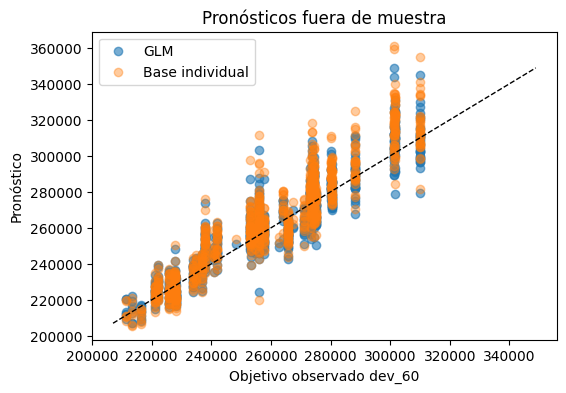

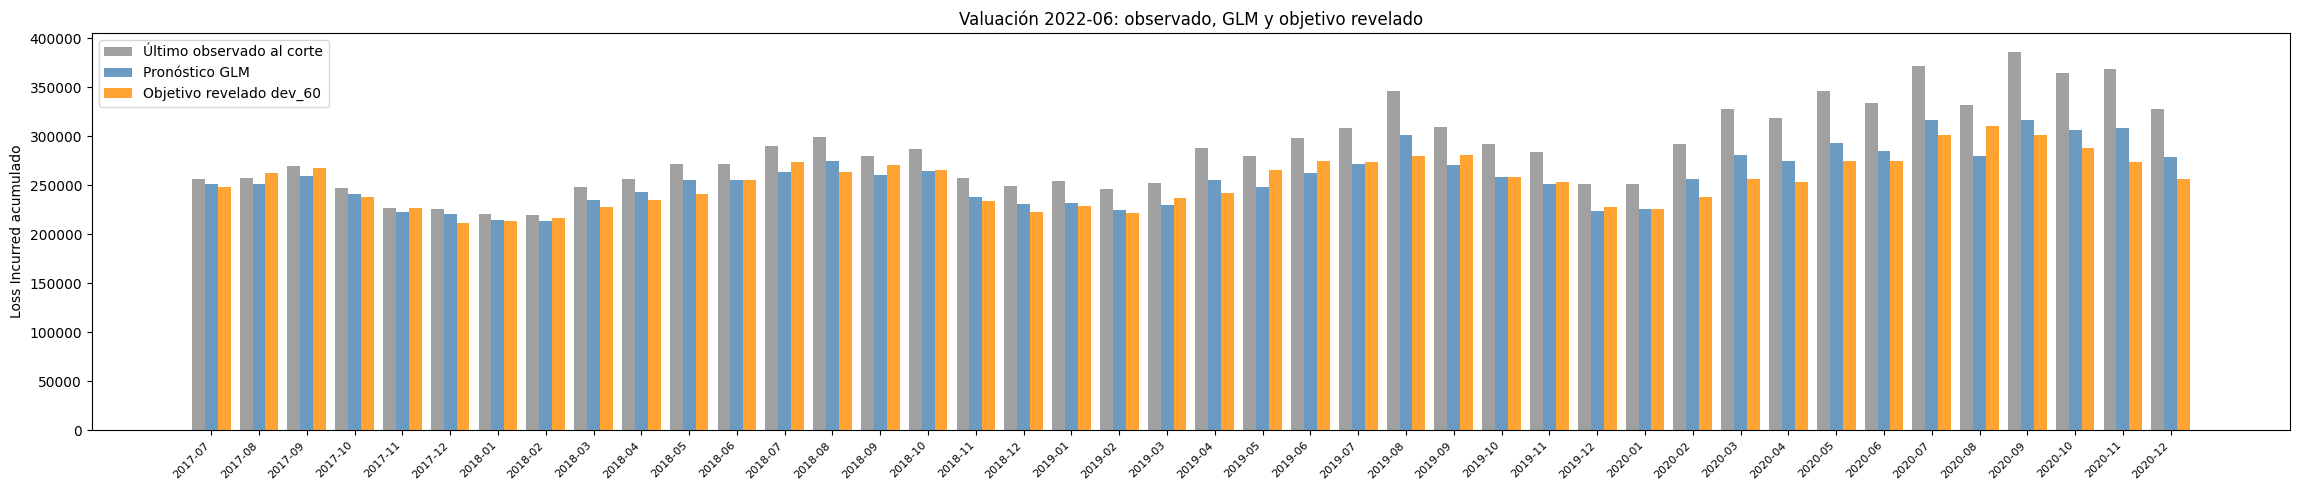

In [6]:
def metricas_modelo(datos: pd.DataFrame, columna_prediccion: str) -> dict:
    validos = datos.dropna(subset=['target', columna_prediccion]).copy()
    error = validos[columna_prediccion] - validos['target']
    return {
        'n_scored': len(validos),
        'wape_pct': wape(validos['target'], validos[columna_prediccion]),
        'bias_pct': 100 * error.sum() / validos['target'].sum(),
        'rmse': np.sqrt((error ** 2).mean()),
        'reserve_error': error.sum(),
    }


fecha_scoring_periodo = pd.Period(FECHA_SCORING, freq='M')
scored = predicciones[
    predicciones['target_valuation'].map(lambda x: pd.Period(x, freq='M')) <= fecha_scoring_periodo
].copy()

if scored.empty:
    print('No hay objetivos revelados en la fecha de scoring.')
else:
    resumen = pd.DataFrame([
        {'model_type': 'GLM stacking', **metricas_modelo(scored, 'glm_prediction')},
        {'model_type': 'Mejor candidato individual', **metricas_modelo(scored, 'baseline_prediction')},
    ])
    display(resumen.round(3))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(scored['target'], scored['glm_prediction'], alpha=0.6, label='GLM')
    ax.scatter(scored['target'], scored['baseline_prediction'], alpha=0.4, label='Base individual')
    limite_min = min(scored['target'].min(), scored['glm_prediction'].min())
    limite_max = max(scored['target'].max(), scored['glm_prediction'].max())
    ax.plot([limite_min, limite_max], [limite_min, limite_max], 'k--', linewidth=1)
    ax.set_xlabel(f'Objetivo observado dev_{MADUREZ}')
    ax.set_ylabel('Pronóstico')
    ax.set_title('Pronósticos fuera de muestra')
    ax.legend()
    plt.show()

# ================================================================
# GRÁFICA DE VALUACIÓN: OBSERVADO, GLM Y OBJETIVO REVELADO
# ================================================================

if not scored.empty:
    if FECHA_GRAFICA is None:
        fecha_grafica = (
            scored.groupby('valuation_period')['target']
            .count()
            .idxmax()
        )
    else:
        fecha_grafica = FECHA_GRAFICA

    vista_valuacion = scored[
        scored['valuation_period'] == fecha_grafica
    ].sort_values('accident_period').copy()

    if vista_valuacion.empty:
        print(f"No hay objetivos revelados para {fecha_grafica}.")
    else:
        posiciones = np.arange(len(vista_valuacion))
        ancho = 0.27
        fig, ax = plt.subplots(
            figsize=(max(10, len(vista_valuacion) * 0.55), 5)
        )
        ax.bar(
            posiciones - ancho,
            vista_valuacion['latest_actual'],
            width=ancho,
            label='Último observado al corte',
            color='gray',
            alpha=0.75,
        )
        ax.bar(
            posiciones,
            vista_valuacion['glm_prediction'],
            width=ancho,
            label='Pronóstico GLM',
            color='steelblue',
            alpha=0.80,
        )
        ax.bar(
            posiciones + ancho,
            vista_valuacion['target'],
            width=ancho,
            label=f'Objetivo revelado dev_{MADUREZ}',
            color='darkorange',
            alpha=0.80,
        )
        ax.set_xticks(posiciones)
        ax.set_xticklabels(
            vista_valuacion['accident_period'],
            rotation=45,
            ha='right',
            fontsize=8,
        )
        ax.set_ylabel('Loss Incurred acumulado')
        ax.set_title(
            f'Valuación {fecha_grafica}: observado, GLM y objetivo revelado'
        )
        ax.legend()
        plt.tight_layout()
        plt.show()


## Paso 5 Lectura de resultados

Compara GLM stacking contra Mejor candidato individual usando WAPE, sesgo, RMSE y reserve error. El GLM sólo es una mejora si supera a la base individual en la misma población fuera de muestra y no introduce un sesgo de reserva material.

Si el GLM pierde, conserva el candidato individual. Si gana de forma consistente, repite el experimento con otras fechas y una madurez distinta antes de usarlo para reservas finales.

La gráfica final muestra, para una valuación, el último valor disponible al corte, el pronóstico GLM y el valor que se reveló posteriormente en dev_60. Usa FECHA_GRAFICA para elegir una fecha concreta; con None se selecciona automáticamente la fecha con más objetivos revelados.